In [10]:
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

In [11]:
data = pd.read_csv("car_acceptability.csv")
df = pd.DataFrame(data)
df

,buying price,maintenance cost,number of doors,number of persons,lug_boot,safety,evaluation
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5,5,med,med,good
1723,low,low,5,5,med,high,vgood
1724,low,low,5,5,big,low,unacc
1725,low,low,5,5,big,med,good


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   buying price       1727 non-null   object
 1   maintenance cost   1727 non-null   object
 2   number of doors    1727 non-null   int64 
 3   number of persons  1727 non-null   int64 
 4   lug_boot           1727 non-null   object
 5   safety             1727 non-null   object
 6   evaluation         1727 non-null   object
dtypes: int64(2), object(5)
memory usage: 94.6+ KB


In [13]:
df.describe()

,number of doors,number of persons
count,1727.000000,1727.000000
mean,3.500869,3.667632
std,1.118098,1.247296
min,2.000000,2.000000
25%,3.000000,2.000000
50%,4.000000,4.000000
75%,4.500000,5.000000
max,5.000000,5.000000


In [6]:
df.dtypes

buying price         object
maintenance cost     object
number of doors       int64
number of persons     int64
lug_boot             object
safety               object
evaluation           object
dtype: object

In [7]:
df.isnull().sum()

buying price         0
maintenance cost     0
number of doors      0
number of persons    0
lug_boot             0
safety               0
evaluation           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.evaluation.unique()

array(['unacc', 'acc', 'vgood', 'good'], dtype=object)

In [17]:
le = LabelEncoder()

df["buying price"] = le.fit_transform(df["buying price"])
df["maintenance cost"] = le.fit_transform(df["maintenance cost"])
df["lug_boot"] = le.fit_transform(df["lug_boot"])
df["safety"] = le.fit_transform(df["safety"])
df["evaluation"] = le.fit_transform(df["evaluation"])
df

,buying price,maintenance cost,number of doors,number of persons,lug_boot,safety,evaluation
0,3,3,2,2,2,2,2
1,3,3,2,2,2,0,2
2,3,3,2,2,1,1,2
3,3,3,2,2,1,2,2
4,3,3,2,2,1,0,2
...,...,...,...,...,...,...,...
1722,1,1,5,5,1,2,1
1723,1,1,5,5,1,0,3
1724,1,1,5,5,0,1,2
1725,1,1,5,5,0,2,1


In [19]:
X = df.drop("evaluation", axis =1)
Y = df["evaluation"]
df

,buying price,maintenance cost,number of doors,number of persons,lug_boot,safety,evaluation
0,3,3,2,2,2,2,2
1,3,3,2,2,2,0,2
2,3,3,2,2,1,1,2
3,3,3,2,2,1,2,2
4,3,3,2,2,1,0,2
...,...,...,...,...,...,...,...
1722,1,1,5,5,1,2,1
1723,1,1,5,5,1,0,3
1724,1,1,5,5,0,1,2
1725,1,1,5,5,0,2,1


In [20]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.20, random_state = 42)

In [21]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
Y_pred = rf.predict(X_test)

In [23]:
print("Accuracy:", accuracy_score(Y_test, Y_pred))

Accuracy: 0.9624277456647399


In [24]:
print("/nConfusion Matrix:/n", confusion_matrix(Y_test,Y_pred))

/nConfusion Matrix:/n [[ 72   1   3   1]
 [  2  10   0   3]
 [  1   0 236   0]
 [  2   0   0  15]]


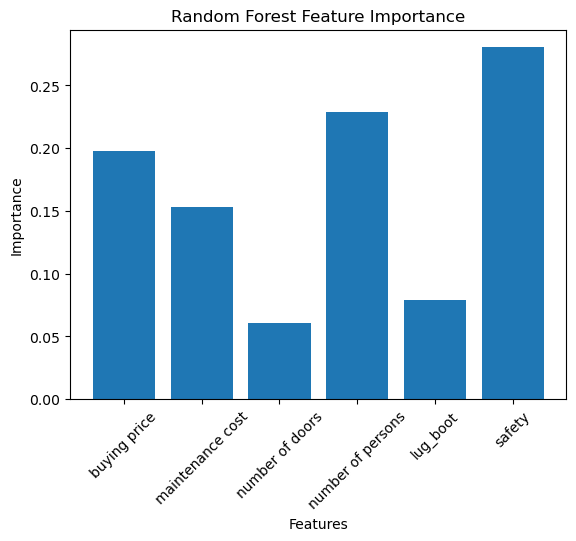

In [26]:
import matplotlib.pyplot as plt
importance = rf.feature_importances_
plt.bar(X.columns, importance)
plt.xticks(rotation = 45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()